In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
from os import path
path="/content/drive/MyDrive/MachineLearningPraktikum/Praktikum10/data"

In [33]:
df = pd.read_csv(path + "/weather_classification_data.csv")
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy


In [34]:
# --- 2. Pemisahan Fitur dan Target ---
X = df.drop('Weather Type', axis=1)
y = df['Weather Type']

In [35]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- 3. Preprocessing Data ---

# Identifikasi kolom numerik dan kategorikal
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Buat pipeline untuk preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [36]:
# --- 4. Pembagian Data Latih dan Uji ---
# Menggunakan 70% data untuk melatih dan 30% untuk menguji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Mencari nilai K optimal menggunakan Cross-Validation...
Nilai K optimal adalah: 3
--------------------------------------------------


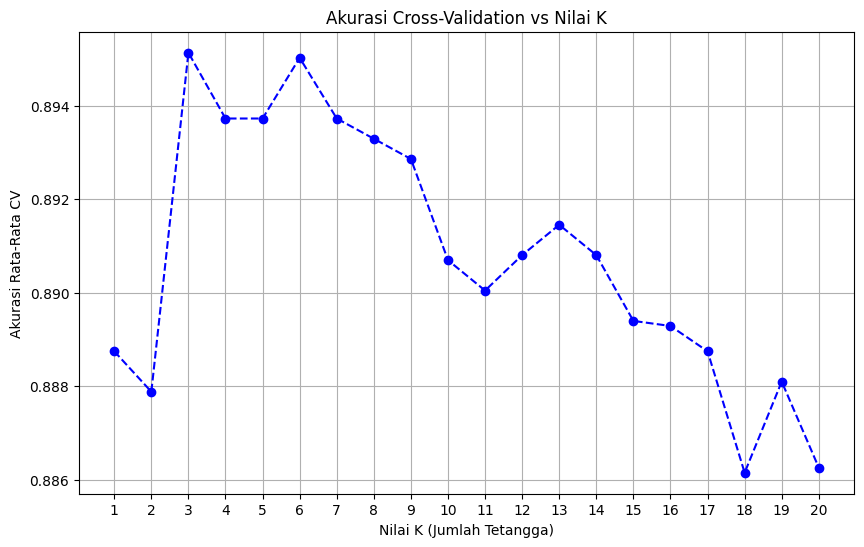

In [27]:
# --- 5. Hyperparameter Tuning (Mencari K Optimal) ---

# Tentukan rentang K yang akan diuji
k_range = range(1, 21)
cv_scores = []

print("Mencari nilai K optimal menggunakan Cross-Validation...")

for k in k_range:
    # Buat pipeline KNN dengan preprocessing
    knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', KNeighborsClassifier(n_neighbors=k))])

    # Lakukan 5-fold Cross-Validation
    scores = cross_val_score(knn_pipeline, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Tentukan K dengan akurasi rata-rata tertinggi
optimal_k = k_range[np.argmax(cv_scores)]

print(f"Nilai K optimal adalah: {optimal_k}")
print("-" * 50)

# Visualisasi K vs Akurasi
plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, marker='o', linestyle='--', color='blue')
plt.title('Akurasi Cross-Validation vs Nilai K')
plt.xlabel('Nilai K (Jumlah Tetangga)')
plt.ylabel('Akurasi Rata-Rata CV')
plt.xticks(k_range)
plt.grid(True)
plt.show() # Di Colab, plt.show() akan menampilkan gambar secara interaktif
plt.close()

In [28]:
# --- 6. Pelatihan Model Final dengan K Optimal ---
knn_final = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', KNeighborsClassifier(n_neighbors=optimal_k))])

knn_final.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Temperature', 'Humidity',
                                                   'Wind Speed',
                                                   'Precipitation (%)',
                                                   'Atmospheric Pressure',
                                                   'UV Index',
                                                   'Visibility (km)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Cloud Cover', 'Season',
                                                   'Location'])])),
                ('classifier', KNeighborsClassifier(n_neighbors=3))])

Akurasi Model KNN pada Data Uji (K=3): 0.8937 atau 89.37%

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.82      0.89      0.86       990
       Rainy       0.88      0.90      0.89       990
       Snowy       0.94      0.91      0.92       990
       Sunny       0.95      0.88      0.91       990

    accuracy                           0.89      3960
   macro avg       0.90      0.89      0.89      3960
weighted avg       0.90      0.89      0.89      3960



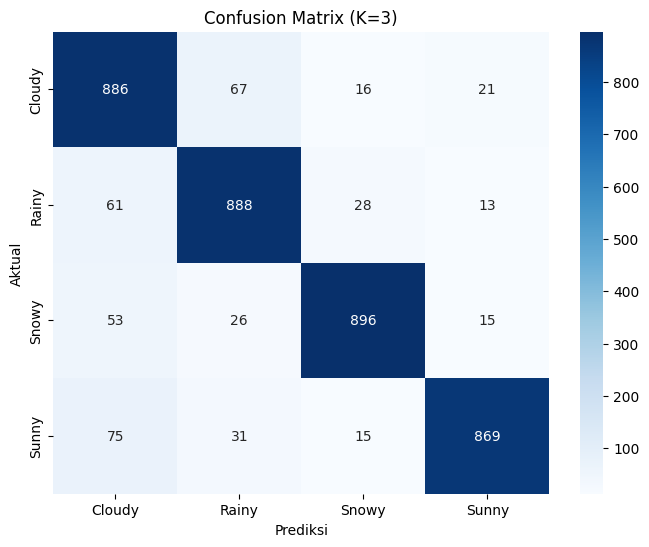

In [29]:
# --- 7. Evaluasi Model ---
y_pred = knn_final.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi Model KNN pada Data Uji (K={optimal_k}): {accuracy:.4f} atau {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title(f'Confusion Matrix (K={optimal_k})')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()
plt.close()